# Notebook 06 — Prophet Model
**CIS6035 IHMS — Somerset Mirissa Beach Hotel**

Steps:
1. Format data for Prophet (ds, y)
2. Build Sri Lanka public holiday dataframe
3. Tune `changepoint_prior_scale`
4. Fit on train set
5. Forecast validation horizon
6. Metrics: RMSE, MAE, MAPE
7. Component plots
8. Save model artifact

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import joblib
import os
from prophet import Prophet

warnings.filterwarnings('ignore')
os.makedirs('../models', exist_ok=True)
os.makedirs('../docs/figures', exist_ok=True)

plt.rcParams['figure.figsize'] = (14, 5)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred))**2))
def mae(y_true, y_pred):
    return np.mean(np.abs(np.array(y_true) - np.array(y_pred)))
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

c:\Users\Hi\Documents\final-project\backend\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
# Load splits
train = pd.read_csv('../data/splits/train.csv', index_col='date', parse_dates=True)['occupancy_rate']
val   = pd.read_csv('../data/splits/val.csv',   index_col='date', parse_dates=True)['occupancy_rate']
test  = pd.read_csv('../data/splits/test.csv',  index_col='date', parse_dates=True)['occupancy_rate']

# Format for Prophet
def to_prophet_df(series):
    return series.reset_index().rename(columns={'date': 'ds', 'occupancy_rate': 'y'})

train_df = to_prophet_df(train)
val_df   = to_prophet_df(val)
test_df  = to_prophet_df(test)

print('Prophet format:', train_df.shape)
train_df.head()

Prophet format: (365, 2)


,ds,y
0,2023-01-01,0.80
1,2023-01-02,0.73
2,2023-01-03,0.73
3,2023-01-04,0.80
4,2023-01-05,0.87


In [3]:
# Sri Lanka public holidays (2023-2025)
lk_holidays = pd.DataFrame({
    'holiday': [
        'Thai Pongal', 'National Day', 'Maha Sivarathri', 'Good Friday',
        'Sinhala & Tamil New Year', 'Labour Day', 'Vesak Full Moon',
        'Id Ul Fitr', 'Poson Full Moon', 'Id Ul Alha', 'Milad Un Nabi',
        'Christmas Day', 'Deepavali', 'New Year\'s Day',
    ] * 3,
    'ds': pd.to_datetime([
        # 2023
        '2023-01-15', '2023-02-04', '2023-02-18', '2023-04-07',
        '2023-04-14', '2023-05-01', '2023-05-05',
        '2023-04-22', '2023-06-03', '2023-06-29', '2023-09-27',
        '2023-12-25', '2023-11-12', '2023-01-01',
        # 2024
        '2024-01-15', '2024-02-04', '2024-03-08', '2024-03-29',
        '2024-04-13', '2024-05-01', '2024-05-23',
        '2024-04-10', '2024-06-22', '2024-06-17', '2024-09-15',
        '2024-12-25', '2024-10-31', '2024-01-01',
        # 2025
        '2025-01-14', '2025-02-04', '2025-02-26', '2025-04-18',
        '2025-04-14', '2025-05-01', '2025-05-12',
        '2025-03-31', '2025-06-11', '2025-06-07', '2025-09-05',
        '2025-12-25', '2025-10-20', '2025-01-01',
    ]),
})
print(f'Holidays defined: {len(lk_holidays)}')

Holidays defined: 42


In [4]:
# Tune changepoint_prior_scale
cps_values = [0.001, 0.01, 0.1, 0.5]
cps_results = []

for cps in cps_values:
    m = Prophet(
        changepoint_prior_scale=cps,
        holidays=lk_holidays,
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
    )
    m.add_seasonality(name='quarterly', period=91.25, fourier_order=5)
    m.fit(train_df)
    
    future = m.make_future_dataframe(periods=len(val), freq='D')
    forecast = m.predict(future)
    val_forecast = forecast.tail(len(val))
    
    val_pred = np.clip(val_forecast['yhat'].values, 0, 1)
    r = rmse(val, val_pred)
    cps_results.append({'cps': cps, 'val_rmse': r})
    print(f'  cps={cps:6.3f}  RMSE={r:.4f}')

best_cps = min(cps_results, key=lambda x: x['val_rmse'])['cps']
print(f'\nBest changepoint_prior_scale: {best_cps}')

14:59:15 - cmdstanpy - INFO - Chain [1] start processing
14:59:18 - cmdstanpy - INFO - Chain [1] done processing
14:59:18 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
14:59:18 - cmdstanpy - INFO - Chain [1] start processing
14:59:23 - cmdstanpy - INFO - Chain [1] done processing


  cps= 0.001  RMSE=0.2585


14:59:26 - cmdstanpy - INFO - Chain [1] start processing
14:59:26 - cmdstanpy - INFO - Chain [1] done processing


  cps= 0.010  RMSE=0.0955


14:59:28 - cmdstanpy - INFO - Chain [1] start processing
14:59:28 - cmdstanpy - INFO - Chain [1] done processing


  cps= 0.100  RMSE=0.0948


14:59:32 - cmdstanpy - INFO - Chain [1] start processing
14:59:33 - cmdstanpy - INFO - Chain [1] done processing


  cps= 0.500  RMSE=0.0933

Best changepoint_prior_scale: 0.5


In [5]:
# Fit final Prophet with best cps
m = Prophet(
    changepoint_prior_scale=best_cps,
    holidays=lk_holidays,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.9,
)
m.add_seasonality(name='quarterly', period=91.25, fourier_order=5)
m.fit(train_df)

print('Prophet model fitted.')

14:59:53 - cmdstanpy - INFO - Chain [1] start processing
14:59:53 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.


In [6]:
# Forecast validation set
future = m.make_future_dataframe(periods=len(val), freq='D')
forecast = m.predict(future)
val_forecast = forecast.tail(len(val))

val_pred = np.clip(val_forecast['yhat'].values, 0, 1)
val_lower = np.clip(val_forecast['yhat_lower'].values, 0, 1)
val_upper = np.clip(val_forecast['yhat_upper'].values, 0, 1)

val_rmse = rmse(val, val_pred)
val_mae  = mae(val, val_pred)
val_mape = mape(val, val_pred)

print(f'Prophet Validation Metrics (cps={best_cps}):')
print(f'  RMSE: {val_rmse:.4f}')
print(f'  MAE:  {val_mae:.4f}')
print(f'  MAPE: {val_mape:.2f}%')

Prophet Validation Metrics (cps=0.5):
  RMSE: 0.0933
  MAE:  0.0717
  MAPE: 13.82%


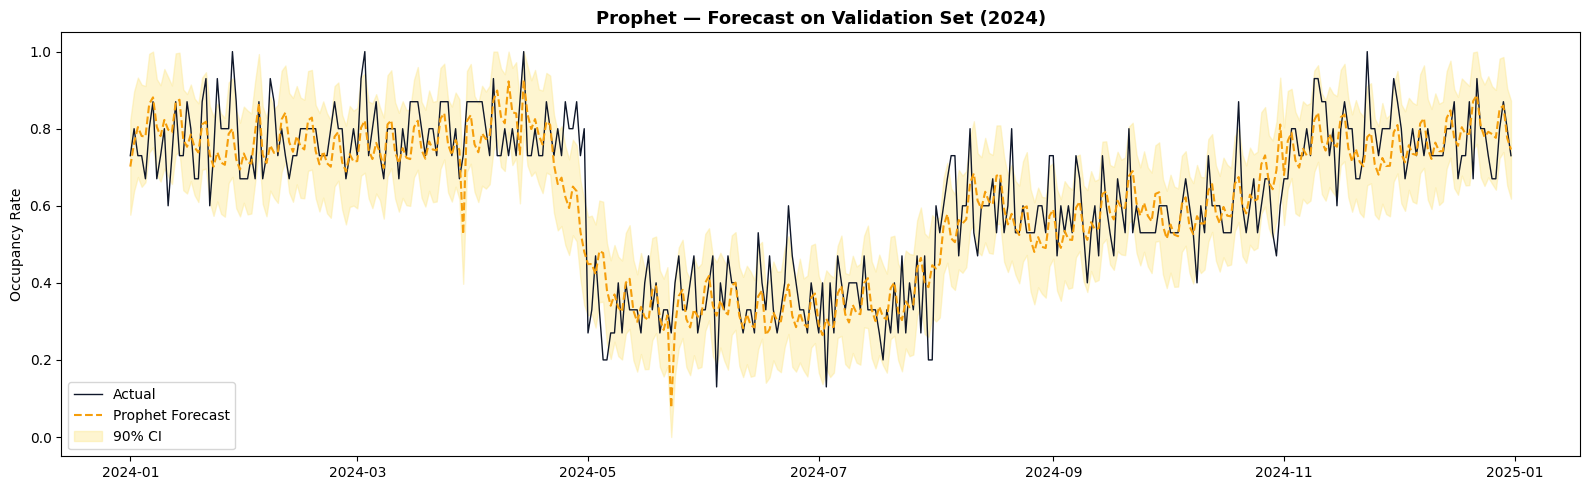

In [7]:
# Forecast + confidence band plot
plt.figure(figsize=(16, 5))
plt.plot(val.index, val.values, label='Actual', color='#0f172a', linewidth=1)
plt.plot(val.index, val_pred, label='Prophet Forecast', color='#f59e0b', linewidth=1.5, linestyle='--')
plt.fill_between(val.index, val_lower, val_upper, color='#fde68a', alpha=0.4, label='90% CI')
plt.title('Prophet — Forecast on Validation Set (2024)', fontsize=13, fontweight='bold')
plt.ylabel('Occupancy Rate')
plt.legend()
plt.tight_layout()
plt.savefig('../docs/figures/06_prophet_val_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

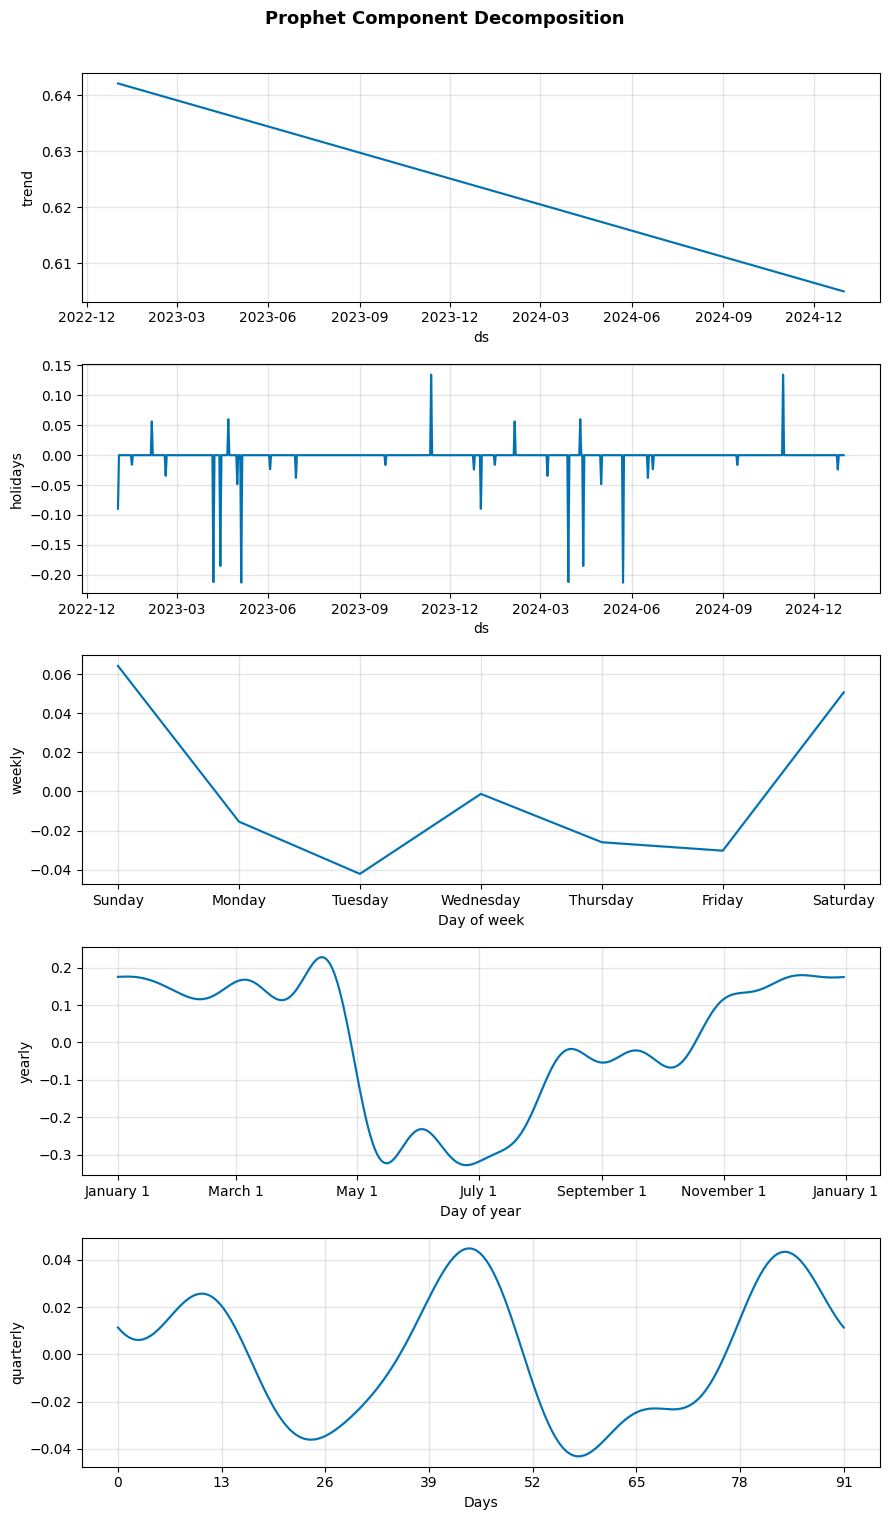

In [8]:
# Component plots
fig = m.plot_components(forecast)
fig.suptitle('Prophet Component Decomposition', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../docs/figures/06_prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Save model
prophet_artifact = {
    'model': m,
    'changepoint_prior_scale': best_cps,
    'val_rmse': val_rmse,
    'val_mae': val_mae,
    'val_mape': val_mape,
    'train_end': str(train.index.max().date()),
}
joblib.dump(prophet_artifact, '../models/prophet_model.pkl')
print('Prophet model saved to models/prophet_model.pkl')

Prophet model saved to models/prophet_model.pkl
